In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.figsize"] = (8, 4)

url = "https://www.datos.gov.co/resource/gt2j-8ykr.json?$limit=10000"
df = pd.read_json(url)


In [33]:
df.head()


,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento,departamento_nom,ciudad_municipio,ciudad_municipio_nom,edad,unidad_medida,sexo,...,recuperado,fecha_inicio_sintomas,fecha_diagnostico,fecha_recuperado,tipo_recuperacion,per_etn_,fecha_muerte,nom_grupo_,pais_viajo_1_cod,pais_viajo_1_nom
0,2020-12-24 00:00:00,1556979,2020-12-22 00:00:00,76,VALLE,76001,CALI,67,1,F,...,Recuperado,2020-12-21 00:00:00,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN,NaN,NaN,NaN
1,2020-12-24 00:00:00,1556980,2020-12-19 00:00:00,76,VALLE,76001,CALI,66,1,F,...,Recuperado,2020-12-07 00:00:00,2020-12-23 00:00:00,2020-12-25 00:00:00,Tiempo,6,NaN,NaN,NaN,NaN
2,2020-12-24 00:00:00,1556981,2020-12-19 00:00:00,76,VALLE,76001,CALI,68,1,F,...,Recuperado,2020-12-18 00:00:00,2020-12-22 00:00:00,2021-01-01 00:00:00,Tiempo,6,NaN,NaN,NaN,NaN
3,2020-12-24 00:00:00,1556982,2020-12-22 00:00:00,76,VALLE,76001,CALI,74,1,F,...,Fallecido,2020-12-17 00:00:00,2020-12-23 00:00:00,NaN,NaN,6,2020-12-30 00:00:00,NaN,NaN,NaN
4,2020-12-24 00:00:00,1556983,2020-12-22 00:00:00,76,VALLE,76001,CALI,65,1,F,...,Recuperado,2020-12-21 00:00:00,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN,NaN,NaN,NaN


In [34]:
df.shape

(10000, 23)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha_reporte_web      10000 non-null  object 
 1   id_de_caso             10000 non-null  int64  
 2   fecha_de_notificaci_n  10000 non-null  object 
 3   departamento           10000 non-null  int64  
 4   departamento_nom       10000 non-null  object 
 5   ciudad_municipio       10000 non-null  int64  
 6   ciudad_municipio_nom   10000 non-null  object 
 7   edad                   10000 non-null  int64  
 8   unidad_medida          10000 non-null  int64  
 9   sexo                   10000 non-null  object 
 10  fuente_tipo_contagio   10000 non-null  object 
 11  ubicacion              10000 non-null  object 
 12  estado                 10000 non-null  object 
 13  recuperado             10000 non-null  object 
 14  fecha_inicio_sintomas  9383 non-null   object 
 15  fec

In [36]:
df.describe()

,id_de_caso,departamento,ciudad_municipio,edad,unidad_medida,per_etn_,pais_viajo_1_cod
count,1.000000e+04,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,2.0
mean,9.603816e+05,1065.624100,30924.758200,40.31960,1.003900,5.882200,484.0
std,6.211799e+05,5089.771377,27285.335811,17.68062,0.066972,0.615598,0.0
min,1.861700e+04,5.000000,5001.000000,1.00000,1.000000,1.000000,484.0
25%,4.754108e+05,11.000000,11001.000000,27.00000,1.000000,6.000000,484.0
50%,9.912775e+05,20.000000,15001.000000,37.00000,1.000000,6.000000,484.0
75%,1.408394e+06,68.000000,54405.000000,52.00000,1.000000,6.000000,484.0
max,5.764914e+06,47001.000000,99001.000000,107.00000,3.000000,6.000000,484.0


## Fase 2 — EDA

Ya vimos `head`, `shape`, `info` y `describe()` arriba. Aquí profundizamos: nulos, outliers, forma de la edad, gráficas y relaciones entre variables.


In [37]:
# Valores faltantes: cantidad y % sobre el total de filas
na = df.isna().sum()
tab = pd.DataFrame({"nulos": na, "pct": (na / len(df) * 100).round(1)})
tab[tab["nulos"] > 0].sort_values("nulos", ascending=False)


,nulos,pct
pais_viajo_1_cod,9998,100.0
pais_viajo_1_nom,9998,100.0
nom_grupo_,9864,98.6
fecha_muerte,9651,96.5
fecha_inicio_sintomas,617,6.2
fecha_recuperado,337,3.4
tipo_recuperacion,337,3.4
fecha_diagnostico,4,0.0


In [38]:
# Estrategia de Tratamiento :
df = df.drop(columns=["fecha_inicio_sintomas","fecha_recuperado","fecha_muerte","pais_viajo_1_cod","pais_viajo_1_nom"]) #uelen faltar cuando no aplica (no murió o el caso sigue abierto);
#no conviene inventar fechas.
df["nom_grupo_"] = df["nom_grupo_"].fillna("sin grupo") # se modifica valores y los valores nulos se colocan en "sin Grupo"
df["estado"] = df["estado"].replace(["N/A", "NA"], "desconocido")
df["estado"] = df["estado"].fillna("desconocido")
df["tipo_recuperacion"] = df["estado"].fillna("desconocido")

In [39]:
df.head()

,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento,departamento_nom,ciudad_municipio,ciudad_municipio_nom,edad,unidad_medida,sexo,fuente_tipo_contagio,ubicacion,estado,recuperado,fecha_diagnostico,tipo_recuperacion,per_etn_,nom_grupo_
0,2020-12-24 00:00:00,1556979,2020-12-22 00:00:00,76,VALLE,76001,CALI,67,1,F,Comunitaria,Casa,Leve,Recuperado,2020-12-23 00:00:00,Leve,6,sin grupo
1,2020-12-24 00:00:00,1556980,2020-12-19 00:00:00,76,VALLE,76001,CALI,66,1,F,Comunitaria,Casa,Leve,Recuperado,2020-12-23 00:00:00,Leve,6,sin grupo
2,2020-12-24 00:00:00,1556981,2020-12-19 00:00:00,76,VALLE,76001,CALI,68,1,F,Comunitaria,Casa,Leve,Recuperado,2020-12-22 00:00:00,Leve,6,sin grupo
3,2020-12-24 00:00:00,1556982,2020-12-22 00:00:00,76,VALLE,76001,CALI,74,1,F,Comunitaria,Fallecido,Fallecido,Fallecido,2020-12-23 00:00:00,Fallecido,6,sin grupo
4,2020-12-24 00:00:00,1556983,2020-12-22 00:00:00,76,VALLE,76001,CALI,65,1,F,Comunitaria,Casa,Leve,Recuperado,2020-12-23 00:00:00,Leve,6,sin grupo


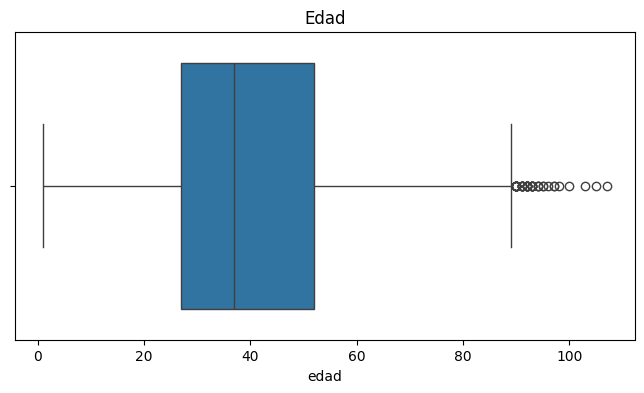

In [40]:
# Edad: boxplot para ver posibles valores extremos
sns.boxplot(x=df["edad"])
plt.title("Edad")
plt.show()


IQR: límites [-10.5, 89.5]  —  fuera por IQR: 46
Z-score: fuera (|z|>3): 13
En datos oficiales las edades extremas suelen conservarse salvo error claro (p. ej. edad imposible).


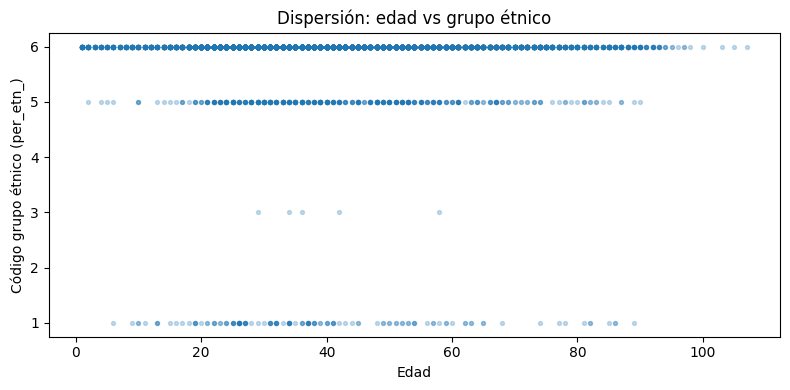

In [41]:
# Outliers en edad: IQR y z-score (regla |z| > 3)
e = df["edad"].dropna()
q1, q3 = e.quantile(0.25), e.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
fuera_iqr = ((df["edad"] < lo) | (df["edad"] > hi)).sum()
z = np.abs(stats.zscore(e))
fuera_z = (z > 3).sum()
print(f"IQR: límites [{lo:.1f}, {hi:.1f}]  —  fuera por IQR: {fuera_iqr}")
print(f"Z-score: fuera (|z|>3): {fuera_z}")
print("En datos oficiales las edades extremas suelen conservarse salvo error claro (p. ej. edad imposible).")

# Diagrama de dispersión entre dos variables numéricas
plt.scatter(df["edad"], df["per_etn_"], alpha=0.25, s=8)
plt.xlabel("Edad")
plt.ylabel("Código grupo étnico (per_etn_)")
plt.title("Dispersión: edad vs grupo étnico")
plt.tight_layout()
plt.show()


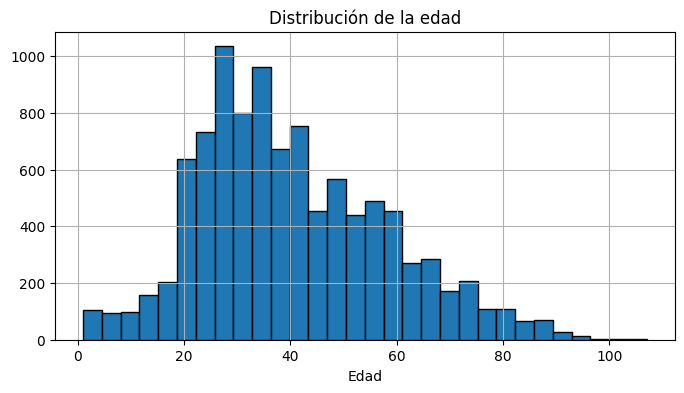

In [42]:
# Histograma de edad
df["edad"].hist(bins=30, edgecolor="black")
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.show()


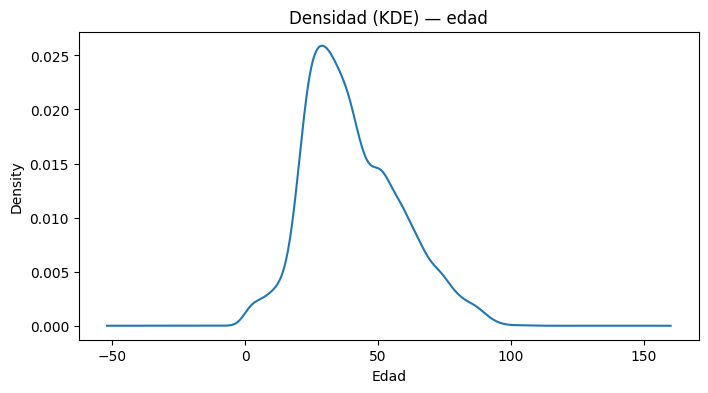

In [43]:
# Curva de densidad (KDE) para la edad
df["edad"].plot.density()
plt.title("Densidad (KDE) — edad")
plt.xlabel("Edad")
plt.show()
